# 03 — 시계열 시각화 (RV_target vs RV_pred)

`log/` 폴더에 저장된 시계열 로그를 들고와서, 평시·9·11·GFC·COVID 4구간별로 실제 RV와 모델 예측을 한 사진에 플롯.

**입력**: `log/{model}/log_{model}_{regime}_{country}.csv` (총 84 파일)

**출력**: 12개 figure (4 regime × 3 country) — 각 figure에 RV_target + 모든 모델 예측

**기본 표시 정책 (변경 가능)**:
- 금융모형: `protocol = static`
- ML 모형: `feature_set = extended`, `protocol = static`
- 위기 구간: phase 영역 음영 (Pre-Lehman blue, Lehman red, Recovery green 등)

## 0. 환경 설정

In [6]:
import os, sys
from pathlib import Path

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive', force_remount=False)
    os.environ['FINTEL_PROJECT_ROOT'] = '/content/drive/MyDrive/대학교/학부4학년_추가/datasciencecapstone/Project'
except ImportError:
    pass

PROJECT_ROOT = Path(os.environ.get('FINTEL_PROJECT_ROOT', Path.cwd().parent))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT = /content/drive/MyDrive/대학교/학부4학년_추가/datasciencecapstone/Project


In [7]:
!pip install -q -r /content/drive/MyDrive/대학교/학부4학년_추가/datasciencecapstone/Project/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 24.6 MB/s eta 0:00:00


In [8]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

from src import config
from src.eval import iter_phases
from src.data_loader import load_dataset

LOG_DIR = PROJECT_ROOT / 'log'
FIG_DIR = PROJECT_ROOT / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('LOG_DIR =', LOG_DIR)
print('FIG_DIR =', FIG_DIR)

LOG_DIR = /content/drive/MyDrive/대학교/학부4학년_추가/datasciencecapstone/Project/log
FIG_DIR = /content/drive/MyDrive/대학교/학부4학년_추가/datasciencecapstone/Project/results/figures


## 1. 로그 로딩 헬퍼

In [9]:
FINANCIAL_MODELS = ['HAR_RV', 'GARCH']
ML_MODELS        = ['Ridge', 'ElasticNet', 'Huber', 'LightGBM', 'XGBoost']
ALL_MODELS       = FINANCIAL_MODELS + ML_MODELS

def load_log(model: str, regime: str, country: str) -> pd.DataFrame:
    """log/{model}/log_{model}_{regime}_{country}.csv 로드."""
    path = LOG_DIR / model / f'log_{model}_{regime}_{country}.csv'
    if not path.exists():
        return pd.DataFrame()  # 비어 있으면 빈 DF 반환
    return pd.read_csv(path, parse_dates=['date'])

def get_pred_series(
    model: str, regime: str, country: str,
    protocol: str = 'static', feature_set: str | None = 'extended',
) -> tuple[pd.Series, pd.Series]:
    """
    (date-indexed) RV_target Series, RV_pred Series 반환.
    ML 모델은 feature_set 인자 사용, 금융 모형은 무시.
    """
    df = load_log(model, regime, country)
    if df.empty:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    # 필터
    if 'feature_set' in df.columns and feature_set is not None:
        df = df[df['feature_set'] == feature_set]
    df = df[df['protocol'] == protocol]
    df = df.sort_values('date').set_index('date')

    return df['RV_target'], df['RV_pred']

# Sanity
for m in ALL_MODELS:
    df = load_log(m, 'normal', 'US')
    print(f'  {m:<12}  rows={len(df)}  cols={list(df.columns) if not df.empty else "(no log file yet)"}')

  HAR_RV        rows=3004  cols=['date', 'protocol', 'RV_target', 'RV_pred']
  GARCH         rows=3004  cols=['date', 'protocol', 'RV_target', 'RV_pred']
  Ridge         rows=9012  cols=['date', 'feature_set', 'protocol', 'RV_target', 'RV_pred']
  ElasticNet    rows=9012  cols=['date', 'feature_set', 'protocol', 'RV_target', 'RV_pred']
  Huber         rows=9012  cols=['date', 'feature_set', 'protocol', 'RV_target', 'RV_pred']
  LightGBM      rows=9012  cols=['date', 'feature_set', 'protocol', 'RV_target', 'RV_pred']
  XGBoost       rows=9012  cols=['date', 'feature_set', 'protocol', 'RV_target', 'RV_pred']


## 2. 한 (regime, country) figure 생성 함수

In [10]:
# 모델별 색상 (시각적 구분 + 일관성)
MODEL_COLORS = {
    'HAR_RV':     '#1f77b4',  # blue
    'GARCH':      '#ff7f0e',  # orange
    'Ridge':      '#2ca02c',  # green
    'ElasticNet': '#9467bd',  # purple
    'Huber':      '#8c564b',  # brown
    'LightGBM':   '#e377c2',  # pink
    'XGBoost':    '#d62728',  # red
}

REGIME_LABELS = {
    'normal': '평시 (Normal)',
    '911':    '9·11',
    'gfc':    'GFC (Global Financial Crisis)',
    'covid':  'COVID',
}

def plot_regime_country(
    regime: str, country: str,
    protocol: str = 'static',
    feature_set: str = 'extended',
    models: list[str] | None = None,
    figsize: tuple = (14, 5),
    save: bool = True,
) -> plt.Figure:
    """
    한 (regime, country) 케이스에 대해 RV_target + 여러 모델 예측을 한 그래프에 플롯.
    """
    if models is None:
        models = ALL_MODELS

    fig, ax = plt.subplots(figsize=figsize)

    # 첫 모델로부터 RV_target 가져오기 (모든 모델이 같은 test 인덱스)
    rv_target = None
    test_index = None
    for m in models:
        y_t, _ = get_pred_series(m, regime, country, protocol, feature_set)
        if not y_t.empty:
            rv_target = y_t
            test_index = y_t.index
            break

    if rv_target is None:
        ax.text(0.5, 0.5, f'No log data for {regime}/{country}',
                ha='center', va='center', transform=ax.transAxes, fontsize=14, color='gray')
        return fig

    # RV_target (실제) — 검정색 굵은 선
    ax.plot(rv_target.index, rv_target.values, color='black', lw=1.5, label='RV_target (실제)')

    # 각 모델 예측
    for m in models:
        _, y_p = get_pred_series(m, regime, country, protocol, feature_set)
        if y_p.empty:
            continue
        # ML 모델은 (model, feature_set, protocol)로 라벨, 금융은 (model, protocol)
        if m in ML_MODELS:
            label = f'{m} ({feature_set}, {protocol})'
        else:
            label = f'{m} ({protocol})'
        ax.plot(y_p.index, y_p.values,
                color=MODEL_COLORS.get(m, 'gray'),
                lw=0.9, alpha=0.8, label=label)

    # 위기 phase 음영
    if regime != 'normal':
        # iter_phases는 test_df DataFrame이 필요 — DatetimeIndex로 가짜 DF 만들기
        pseudo_test = pd.DataFrame(index=test_index)
        for name, mask, color in iter_phases(pseudo_test, regime):
            if name == 'Full Test' or color is None:
                continue
            idx = test_index[mask]
            if len(idx) > 0:
                ax.axvspan(idx.min(), idx.max(), color=color, alpha=0.12, label=name)

    ax.set_title(
        f'{REGIME_LABELS.get(regime, regime)} / {country}    '
        f'(test: {test_index.min().date()} ~ {test_index.max().date()},  {len(test_index)}일)',
        fontsize=12,
    )
    ax.set_ylabel('RV (variance, %²)')
    ax.set_xlabel('Date')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

    # x축 날짜 포맷팅 (긴 시계열은 연도 단위, 짧은 건 월 단위)
    if (test_index.max() - test_index.min()).days > 365:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.tight_layout()

    if save:
        out = FIG_DIR / f'{regime}_{country}_{feature_set}_{protocol}.png'
        fig.savefig(out, dpi=120, bbox_inches='tight')
        print(f'  saved: {out.relative_to(PROJECT_ROOT)}')

    return fig

## 3. 전체 그리드 시각화 — 4 regime × 3 country = 12 figure

In [11]:
REGIMES   = ['normal', '911', 'gfc', 'covid']
COUNTRIES = ['US', 'KR', 'JP']

for regime in REGIMES:
    for country in COUNTRIES:
        fig = plot_regime_country(
            regime, country,
            protocol='static',
            feature_set='extended',
            save=True,
        )
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 4. (선택) 단일 케이스 비교 — protocol or tier 변경

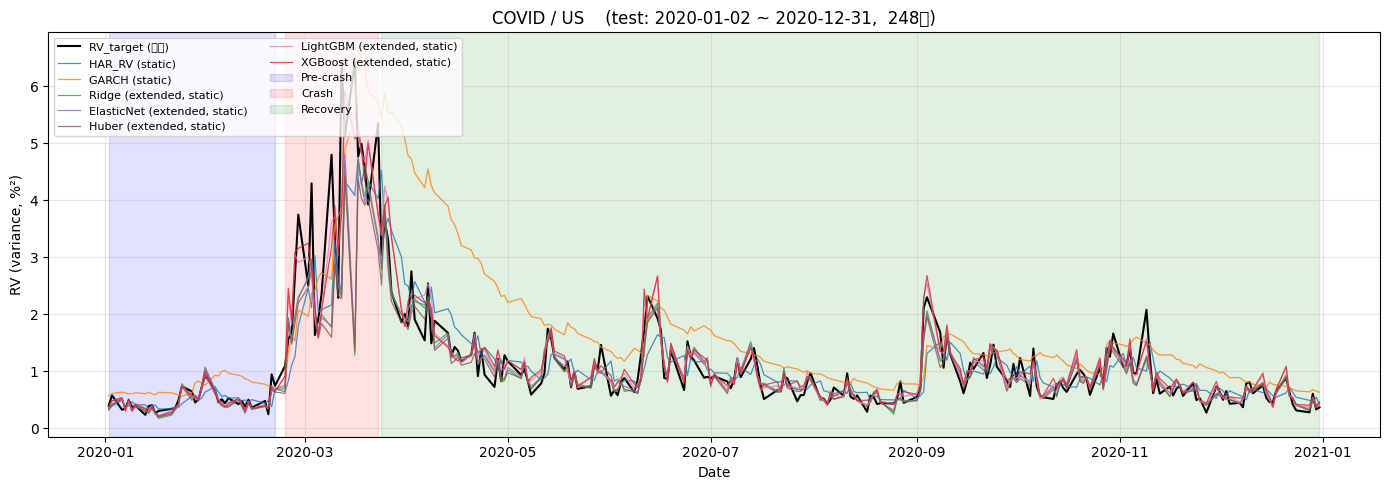

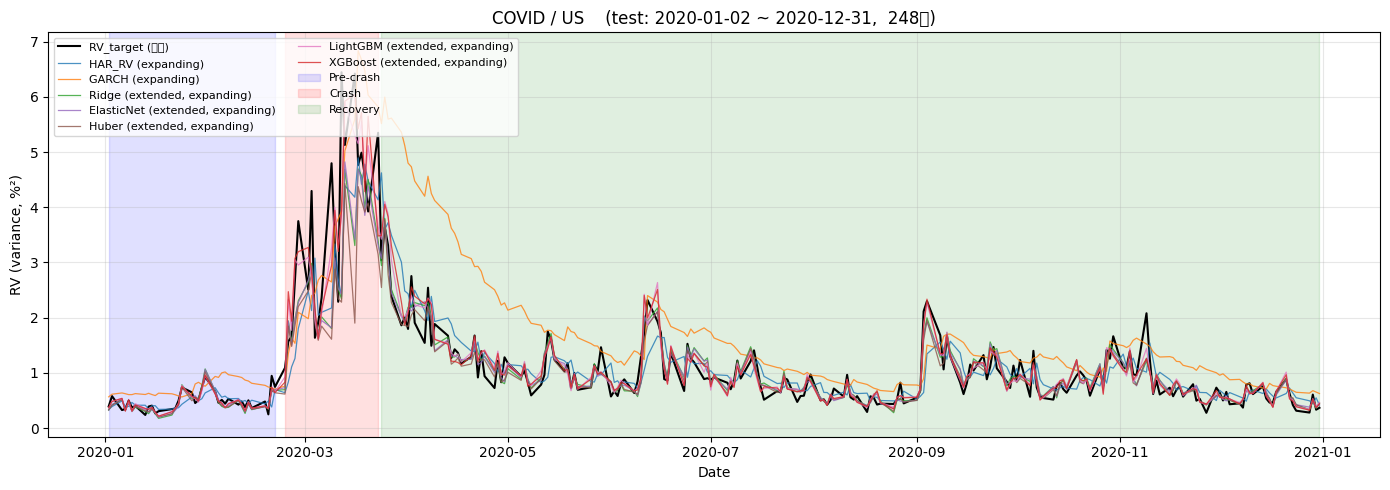

In [12]:
# 같은 regime/country에서 다른 protocol 비교
plot_regime_country('covid', 'US', protocol='static',    feature_set='extended', save=False)
plt.show()
plot_regime_country('covid', 'US', protocol='expanding', feature_set='extended', save=False)
plt.show()

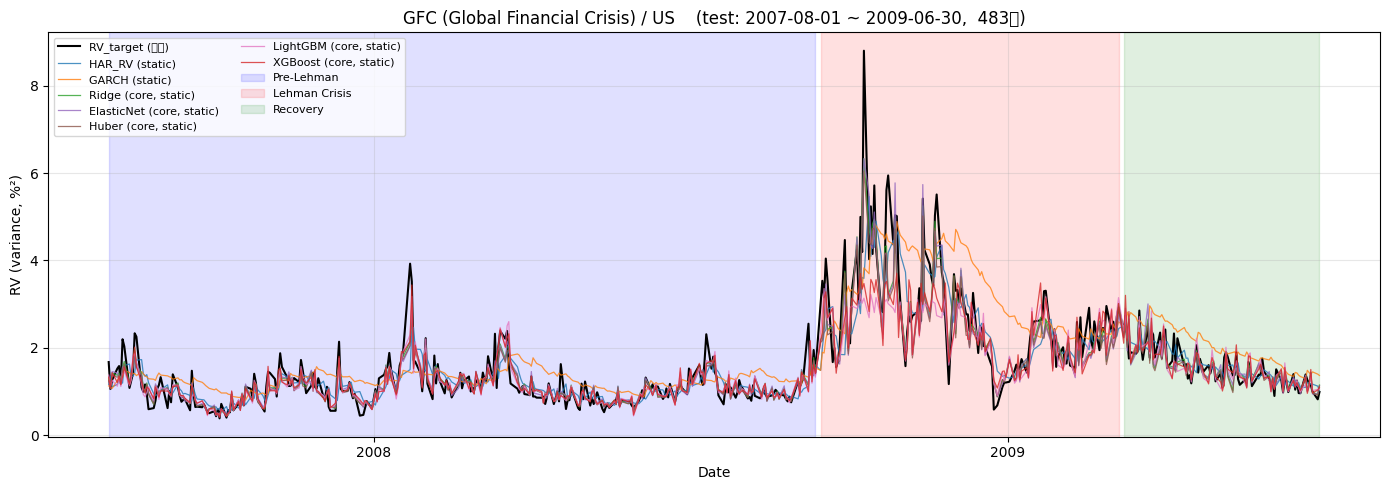

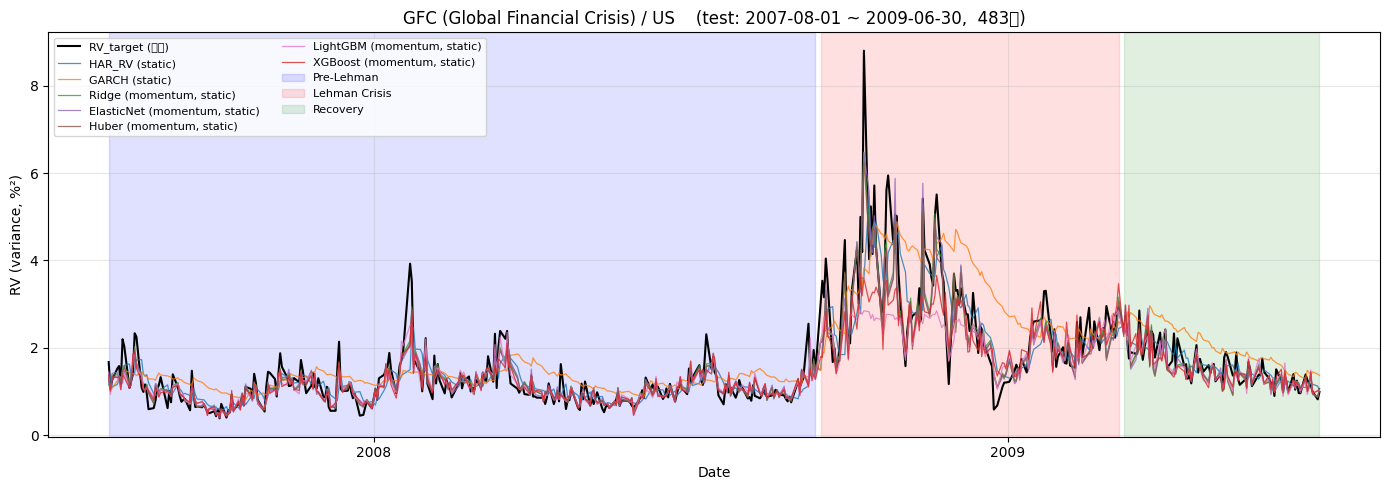

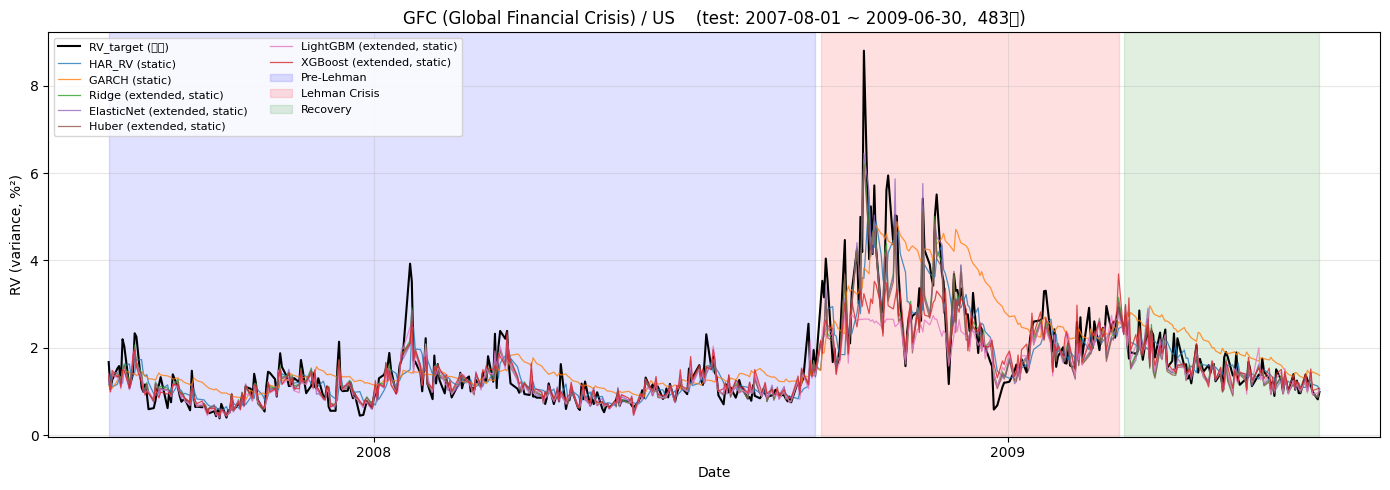

In [13]:
# 같은 regime/country에서 다른 tier 비교 (ML만 영향)
for tier in ['core', 'momentum', 'extended']:
    plot_regime_country('gfc', 'US', protocol='static', feature_set=tier, save=False)
    plt.show()

## 5. (선택) 모델 부류별 분리 비교

금융모형(HAR/GARCH)만, 또는 ML 모형(5개)만 한 그래프에 보고 싶을 때.

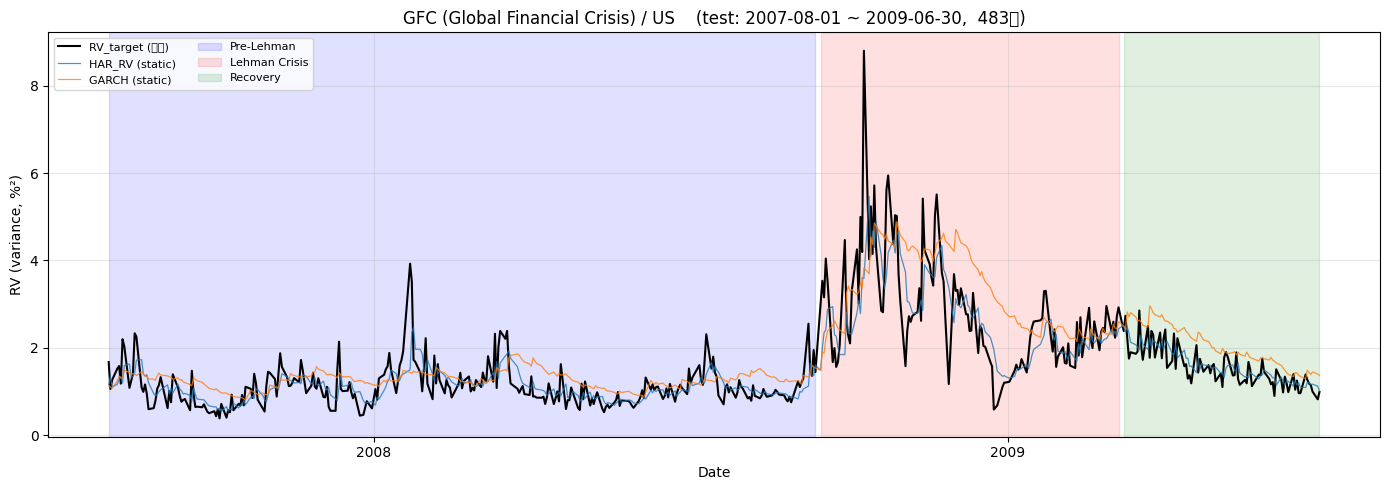

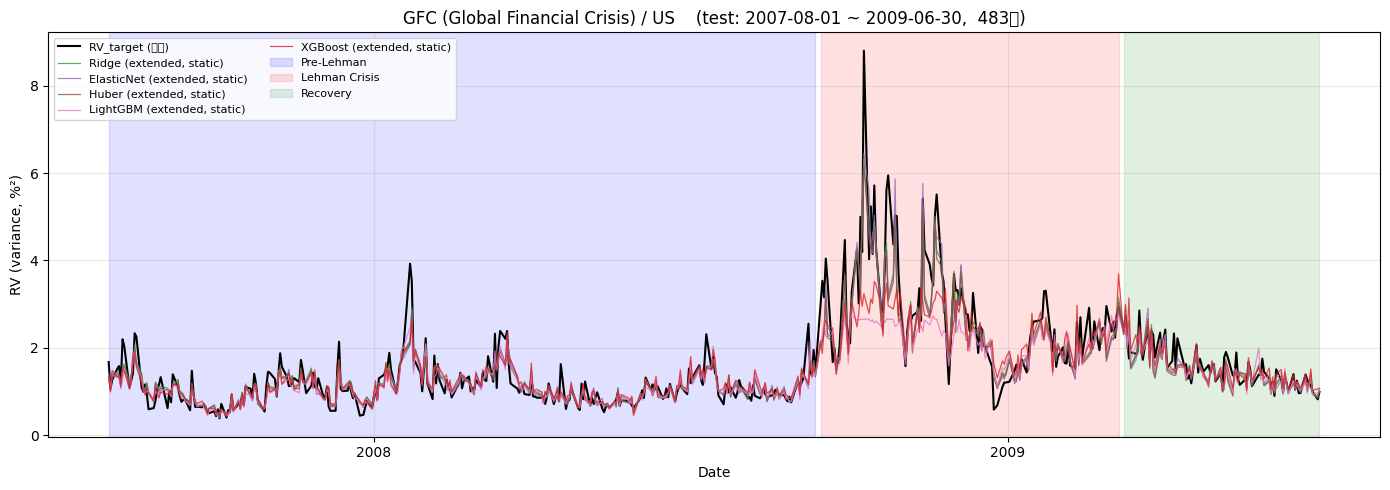

In [14]:
# 금융모형만
plot_regime_country('gfc', 'US', protocol='static', models=FINANCIAL_MODELS, save=False)
plt.show()

# ML 모형만
plot_regime_country('gfc', 'US', protocol='static', feature_set='extended', models=ML_MODELS, save=False)
plt.show()